In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/ecom_data_transformed.csv')
df

,gender,divorced,married,single,login_computer,login_mobile,login_phone,order_fashion,order_grocery,order_laptop,...,hour_spend,device_registered,satisfaction_score,number_address,complain,order_lastyear,coupon_used,order_count,days_lastorder,cashback_amount
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,3.0,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.000000,160.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.000000,121.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.000000,120.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,2.0,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.000000,134.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.0,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.000000,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,3.0,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.000000,151.0
5626,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,3.0,5.0,5.0,6.0,0.0,16.0,1.0,2.0,4.543491,225.0
5627,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,3.0,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.000000,186.0
5628,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,4.0,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.000000,179.0


# CORRELACIONES

In [5]:
corr_matrix = df.corr()
corr_result = corr_matrix['churn']
corr_result.sort_values(ascending=False)

,churn
churn,1.000000
complain,0.250188
single,0.180847
order_mobile _phone,0.154387
order_phone,0.113364
device_registered,0.107939
satisfaction_score,0.105481
city_tier,0.084703
payment_cod,0.083933
login_phone,0.078916


<Axes: >

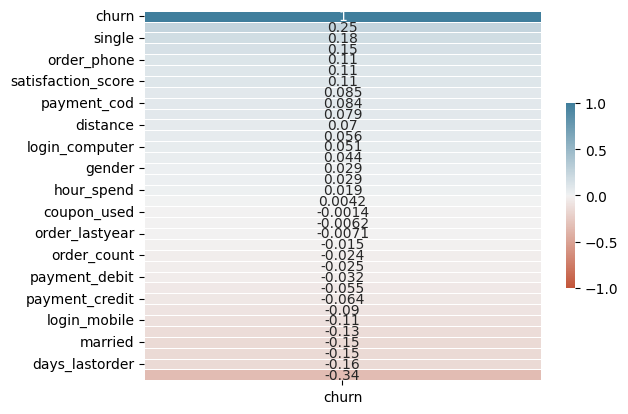

In [6]:
sns.heatmap(
    data=corr_result.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

In [7]:
cols = df.columns
cols = cols.drop('churn')
cols

Index(['gender', 'divorced', 'married', 'single', 'login_computer',
       'login_mobile', 'login_phone', 'order_fashion', 'order_grocery',
       'order_laptop', 'order_phone', 'order_mobile _phone', 'order_others',
       'payment_cc', 'payment_cod', 'payment_cash', 'payment_credit',
       'payment_debit', 'payment_ewallet', 'payment_upi', 'tenure',
       'city_tier', 'distance', 'hour_spend', 'device_registered',
       'satisfaction_score', 'number_address', 'complain', 'order_lastyear',
       'coupon_used', 'order_count', 'days_lastorder', 'cashback_amount'],
      dtype='object')

# ENTRENAMIENTO DE MODELO DE CLASIFICACIÓN CON REGRESIÓN LOGISTICA

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## 1 - IDENTIFICAR VARIABLES

In [8]:
X = df[cols]
y = df['churn']

## 2 - DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## 3 - ESCALAMIENTO DE DATOS

In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4 - ENTRENAMIENTOS

### 4.1 SIN PARAMETROS

In [17]:
model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy}')

Accuracy : 0.9156305506216696


### 4.2 PROBANDO VARIOS PARAMETROS

In [13]:
configs = [
    ('liblinear', 'l1', None),
    ('liblinear', 'l2', None),
    ('saga', 'l1', None),
    ('saga', 'l2', None),
    ('saga', 'elasticnet', 0.5),
    ('lbfgs', 'l2', None),
    ('saga', 'l1', 'balanced'),
    ('saga', 'l2', 'balanced'),
]

In [16]:
results = {}
cont_model = 1
for solver,penalty,class_weight in configs:
    if penalty == 'l1' and solver not in ['liblinear', 'saga']:
        continue  # Algunos solvers no admiten L1
    if penalty == 'elasticnet' and solver != 'saga':
        continue  # Solo 'saga' soporta elasticnet

    model_config = LogisticRegression(solver=solver, penalty=penalty, l1_ratio=0.5 if penalty == 'elasticnet' else None, max_iter=1000)
    model_config.fit(X_train,y_train)
    y_pred = model_config.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    print(f'Accuracy model {cont_model}: {accuracy}')
    results[f'Model {cont_model}'] = accuracy
    cont_model += 1

Accuracy model 1: 0.9156305506216696
Accuracy model 2: 0.9156305506216696
Accuracy model 3: 0.9156305506216696
Accuracy model 4: 0.9156305506216696
Accuracy model 5: 0.9156305506216696
Accuracy model 6: 0.9156305506216696
Accuracy model 7: 0.9156305506216696
Accuracy model 8: 0.9156305506216696


/tmp/ipython-input-2783166880.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


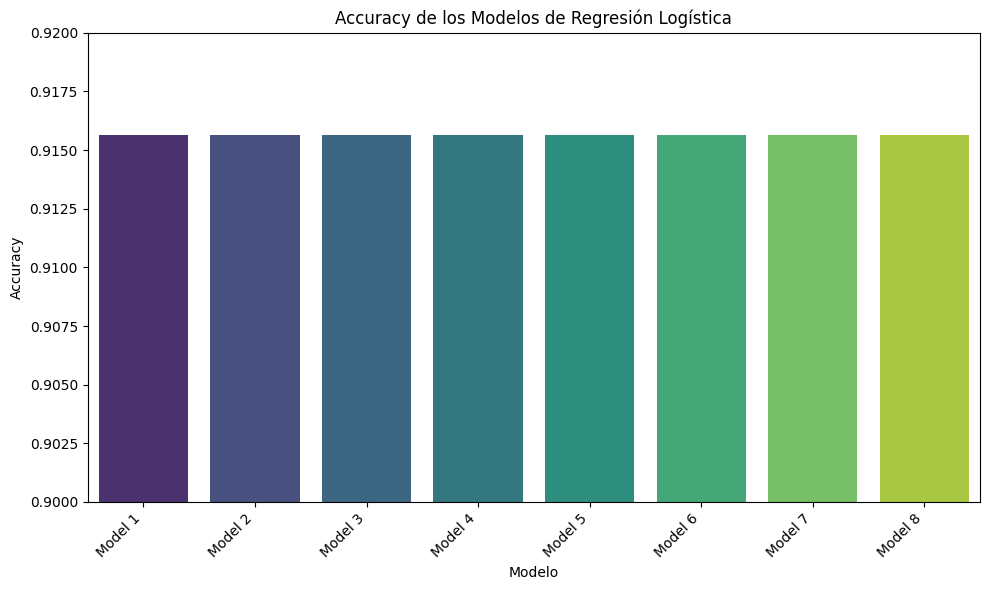

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert the results dictionary to a pandas DataFrame
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')

# Add labels and title
plt.xlabel('Modelo')
plt.ylabel('Accuracy')
plt.title('Accuracy de los Modelos de Regresión Logística')
plt.ylim(0.9, 0.92) # Adjust y-axis limit for better visualization of small differences

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=45, ha='right')

# Display the plot
plt.tight_layout()
plt.show()

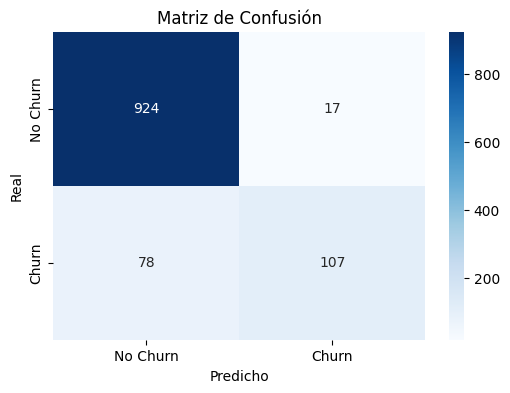

In [19]:
conf_matrix = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()